# Etude de la stabilité des neurones des réseaux du benchmark

In [ ]:
import pandas as pd
import numpy as np

tab = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x200-0.015/2026_03_20_11h14_45s_test-histogramme-relu-relaxee/stable_actives_study.csv")

In [2]:
tab.columns

Index(['Unnamed: 0', 'label', 'data_index', 'Number_actives_stable',
       'Number_inactives_stable', 'Number_targets', 'Stable_Actives_Layer_1',
       'Stable_Inactives_Layer_1', 'Stable_Actives_Layer_2',
       'Stable_Inactives_Layer_2', 'Stable_Actives_Layer_3',
       'Stable_Inactives_Layer_3', 'Stable_Actives_Layer_4',
       'Stable_Inactives_Layer_4', 'Stable_Actives_Layer_5',
       'Stable_Inactives_Layer_5', 'Stable_Actives_Layer_6',
       'Stable_Inactives_Layer_6', 'Stable_Actives_Layer_7',
       'Stable_Inactives_Layer_7', 'Stable_Actives_Layer_8',
       'Stable_Inactives_Layer_8', 'Stable_Actives_Layer_9',
       'Stable_Inactives_Layer_9', 'Stable_Actives_Layer_10',
       'Stable_Inactives_Layer_10'],
      dtype='object')

In [3]:
tab['Stable_Actives_Layer_1']

0     38.0
1     44.0
2     34.0
3     38.0
4     44.0
      ... 
95    41.0
96    47.0
97    35.0
98    38.0
99    35.0
Name: Stable_Actives_Layer_1, Length: 100, dtype: float64

In [4]:
K = 10
n = [784, 200, 200, 200, 200, 200, 200, 200, 200, 200, 10]  # Nombre de neurones par couche (entrée, cachées, sortie)

In [5]:
actives = []
inactives = []
actives_percentage = []
inactives_percentage = []
for k in range(1, K + 1):
    nb_stable_actives_layer_k = tab[f'Stable_Actives_Layer_{k}'].mean()
    nb_stable_inactives_layer_k = tab[f'Stable_Inactives_Layer_{k}'].mean()
    print(
        f"STUDY : Layer {k} - Stable actives neurons: {nb_stable_actives_layer_k} - Stable inactives neurons: {nb_stable_inactives_layer_k}"
    )
    actives.append(nb_stable_actives_layer_k)
    inactives.append(nb_stable_inactives_layer_k)
    actives_percentage.append(nb_stable_actives_layer_k / n[k] * 100)
    inactives_percentage.append(nb_stable_inactives_layer_k / n[k] * 100)

STUDY : Layer 1 - Stable actives neurons: 39.9 - Stable inactives neurons: 146.26
STUDY : Layer 2 - Stable actives neurons: 76.18 - Stable inactives neurons: 90.38
STUDY : Layer 3 - Stable actives neurons: 44.51 - Stable inactives neurons: 129.38
STUDY : Layer 4 - Stable actives neurons: 38.08 - Stable inactives neurons: 125.35
STUDY : Layer 5 - Stable actives neurons: 26.11 - Stable inactives neurons: 131.88
STUDY : Layer 6 - Stable actives neurons: 20.11 - Stable inactives neurons: 123.46
STUDY : Layer 7 - Stable actives neurons: 22.43 - Stable inactives neurons: 101.19
STUDY : Layer 8 - Stable actives neurons: 19.43 - Stable inactives neurons: 93.41
STUDY : Layer 9 - Stable actives neurons: 0.0 - Stable inactives neurons: 83.07
STUDY : Layer 10 - Stable actives neurons: 0.0 - Stable inactives neurons: 0.0


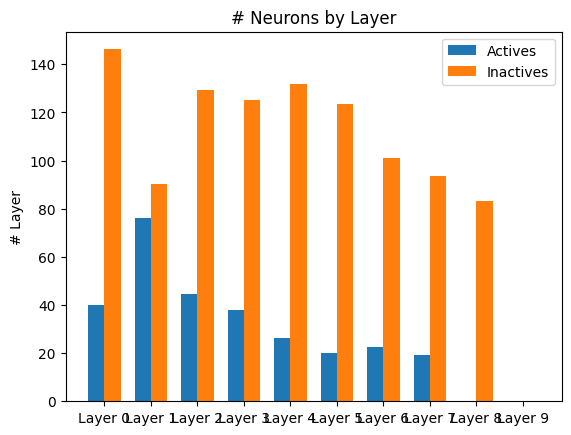

In [6]:
actives = np.array(actives)
inactives = np.array(inactives)

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, K + 1)

# Largeur des barres
width = 0.35

plt.figure()

plt.bar(x - width/2, actives, width, label='Actives')
plt.bar(x + width/2, inactives, width, label='Inactives')

# Labels
plt.ylabel("# Layer")
plt.title("# Neurons by Layer")

# Numéros des couches sur l'axe x
plt.xticks(x, [f"Layer {i}" for i in range(K)])

plt.legend()

plt.show()

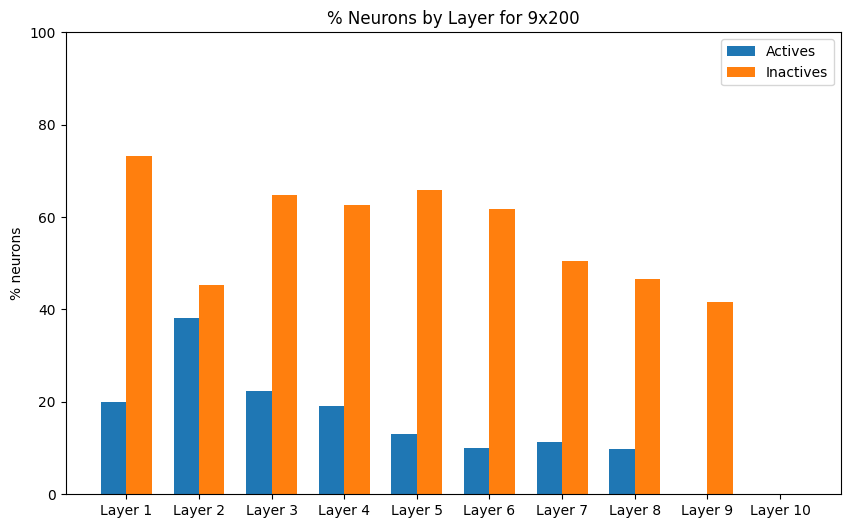

In [7]:

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, K + 1)

# Largeur des barres
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, actives_percentage, width, label='Actives')
plt.bar(x + width/2, inactives_percentage, width, label='Inactives')

# Labels
plt.ylabel("% neurons")
plt.title("% Neurons by Layer for 9x200")

# Numéros des couches sur l'axe x
plt.xticks(x, [f"Layer {i}" for i in range(1, K + 1)])

plt.legend()
plt.ylim(0, 100)

plt.show()

In [2]:
import decimal

In [10]:
d = decimal.Decimal('5.1887')
-d.as_tuple().exponent

4

In [13]:
entier = 6.85
nb_decimals = -decimal.Decimal(entier).as_tuple().exponent
nb_decimals

49

## Comparaison bornes

In [1]:
import pandas as pd

bornes_sdpt = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/6x100-0.026/2026_03_23_18h10_29s_sauvegarde-bornes-SDPt/stable_actives_study.csv")
bornes_sdpu = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/6x100-0.026/2026_03_23_17h54_15s_sauvegarde-bornes/stable_actives_study.csv")

In [3]:
bornes_sdpt.columns

Index(['Unnamed: 0', 'label', 'data_index', 'Number_actives_stable',
       'Number_inactives_stable', 'Number_targets', 'Stable_Actives_Layer_1',
       'Stable_Inactives_Layer_1', 'Stable_Actives_Layer_2',
       'Stable_Inactives_Layer_2',
       ...
       'LB_Layer_7_Neuron_5', 'UB_Layer_7_Neuron_5', 'LB_Layer_7_Neuron_6',
       'UB_Layer_7_Neuron_6', 'LB_Layer_7_Neuron_7', 'UB_Layer_7_Neuron_7',
       'LB_Layer_7_Neuron_8', 'UB_Layer_7_Neuron_8', 'LB_Layer_7_Neuron_9',
       'UB_Layer_7_Neuron_9'],
      dtype='object', length=2808)

In [16]:

def check_values_match(row, index, borne : str, precision : int = 3):
    assert borne in ["LB", "UB"], "Borne must be either 'LB' or 'UB'"
    for col in bornes_sdpt.columns:
        if borne in col:
            if round(row[col], precision) != round(bornes_sdpu.loc[index, col], precision):
            #     print(f"Value mismatch at index {index} for column {col}: {row[col]} != {bornes_sdpu.loc[index, col]}")
                return False
    return True

list_precision = []
for index, row in bornes_sdpt.iterrows():
    for precision in range(10,1, -1):
        all_values_equal_lb = check_values_match(row, index, "LB", precision)
        all_values_equal_ub = check_values_match(row, index, "UB", precision)
        if all_values_equal_lb and all_values_equal_ub:
            print(f"All LB and UB values match for index {index} with precision {precision} decimals.")
            list_precision.append(precision)
            break

All LB and UB values match for index 0 with precision 4 decimals.
All LB and UB values match for index 1 with precision 3 decimals.
All LB and UB values match for index 2 with precision 3 decimals.
All LB and UB values match for index 3 with precision 4 decimals.
All LB and UB values match for index 4 with precision 5 decimals.
All LB and UB values match for index 5 with precision 3 decimals.
All LB and UB values match for index 6 with precision 5 decimals.
All LB and UB values match for index 8 with precision 3 decimals.
All LB and UB values match for index 9 with precision 3 decimals.
All LB and UB values match for index 10 with precision 2 decimals.
All LB and UB values match for index 13 with precision 2 decimals.
All LB and UB values match for index 14 with precision 4 decimals.
All LB and UB values match for index 15 with precision 3 decimals.
All LB and UB values match for index 17 with precision 3 decimals.
All LB and UB values match for index 19 with precision 3 decimals.
All 

In [18]:
import numpy as np

np.mean(list_precision)

np.float64(3.1875)